# Housing Affordability Analysis Across U.S. Metro Areas

This project analyzes **rental housing affordability** across selected major U.S. Metro Areas using data from the **U.S. Census ACS 5-Year dataset**.

The goal is to understand how rental burden differs across major housing markets by comparing:

- `Median Household Income`
- `Median Gross Rent`
- `Rent-to-Income Ratio`

Rather than looking only at rent prices, this project focuses on the **share of monthly income spent on rent**, which gives a clearer view of housing affordability.


## Project Question

The main question of this project is:

> **Which major U.S. Metro Areas have the highest rental housing burden when rent is compared to household income?**

Additional questions:

- Are high-rent Metro Areas always the least affordable?
- Do higher-income Metro Areas have lower rental burden?
- How does `Rent-to-Income Ratio` differ across major rental markets?
- What can this ratio tell us about **housing market pressure**?


In [23]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

## Data Source

This project uses data from the **U.S. Census ACS 5-Year dataset**.

The two main Census variables are:

- `B19013_001E` — Median Household Income
- `B25064_001E` — Median Gross Rent

The analysis uses Metro Area-level data. In the Census API, this geography is listed as:

`metropolitan statistical area/micropolitan statistical area`

Because the raw dataset includes both Metro Areas and Micro Areas, the data will be filtered to keep only **Metro Areas**.


In [24]:
# API key removed for security.
API_KEY = "YOUR_CENSUS_API_KEY"

# ACS 5-Year API URL
url = "https://api.census.gov/data/2023/acs/acs5"

# API request parameters
params = {
    "get": "NAME,B19013_001E,B25064_001E",
    "for": "metropolitan statistical area/micropolitan statistical area:*",
    "key": API_KEY
}

# Request data
response = requests.get(url, params=params)

# Check response
print("Status code:", response.status_code)
print("Response preview:")
print(response.text[:300])

# Convert response to DataFrame
data = response.json()
df = pd.DataFrame(data[1:], columns=data[0])

df.head()

Status code: 200
Response preview:
[["NAME","B19013_001E","B25064_001E","metropolitan statistical area/micropolitan statistical area"],
["Aberdeen, SD Micro Area","70761","796","10100"],
["Aberdeen, WA Micro Area","63539","1018","10140"],
["Abilene, TX Metro Area","66464","1095","10180"],
["Ada, OK Micro Area","62564","880","10220"],


,NAME,B19013_001E,B25064_001E,metropolitan statistical area/micropolitan statistical area
0,"Aberdeen, SD Micro Area",70761,796,10100
1,"Aberdeen, WA Micro Area",63539,1018,10140
2,"Abilene, TX Metro Area",66464,1095,10180
3,"Ada, OK Micro Area",62564,880,10220
4,"Adrian, MI Micro Area",67013,965,10300


## Data Cleaning

The raw Census data needs to be cleaned before analysis.

In this step, I will:

- Rename columns to make them easier to understand
- Convert income and rent values into numeric data types
- Remove Micro Areas and keep only **Metro Areas**

This creates a cleaner dataset focused on the major regional housing markets used in this project.


In [25]:
# Rename columns
df = df.rename(columns={
    "NAME": "metro_area",
    "B19013_001E": "median_household_income",
    "B25064_001E": "median_gross_rent",
    "metropolitan statistical area/micropolitan statistical area": "metro_code"
})

# Convert numeric columns
df["median_household_income"] = pd.to_numeric(df["median_household_income"], errors="coerce")
df["median_gross_rent"] = pd.to_numeric(df["median_gross_rent"], errors="coerce")

# Keep only Metro Areas
df_metro = df[df["metro_area"].str.contains("Metro Area", na=False)].copy()

print("Metro-only dataset shape:", df_metro.shape)

df_metro.head()

Metro-only dataset shape: (393, 4)


,metro_area,median_household_income,median_gross_rent,metro_code
2,"Abilene, TX Metro Area",66464,1095,10180
5,"Aguadilla, PR Metro Area",20800,506,10380
6,"Akron, OH Metro Area",71312,1005,10420
9,"Albany, GA Metro Area",54219,922,10500
10,"Albany, OR Metro Area",73396,1273,10540


## Selected Metro Areas

For the first version of this project, I selected **29 major U.S. Metro Areas**.

This keeps the project focused and manageable while still covering major rental markets across different regions of the United States.

These Metro Areas were selected to represent large and regionally diverse rental markets across the United States.

The selected Metro Areas include large housing markets such as New York, Los Angeles, Chicago, Miami, Seattle, Boston, San Francisco, and Madison.

In [26]:
selected_metros = [
    "New York-Newark-Jersey City, NY-NJ Metro Area",
    "Los Angeles-Long Beach-Anaheim, CA Metro Area",
    "Chicago-Naperville-Elgin, IL-IN Metro Area",
    "Dallas-Fort Worth-Arlington, TX Metro Area",
    "Houston-Pasadena-The Woodlands, TX Metro Area",
    "Washington-Arlington-Alexandria, DC-VA-MD-WV Metro Area",
    "Miami-Fort Lauderdale-West Palm Beach, FL Metro Area",
    "Philadelphia-Camden-Wilmington, PA-NJ-DE-MD Metro Area",
    "Atlanta-Sandy Springs-Roswell, GA Metro Area",
    "Phoenix-Mesa-Chandler, AZ Metro Area",
    "Boston-Cambridge-Newton, MA-NH Metro Area",
    "San Francisco-Oakland-Fremont, CA Metro Area",
    "Riverside-San Bernardino-Ontario, CA Metro Area",
    "Detroit-Warren-Dearborn, MI Metro Area",
    "Seattle-Tacoma-Bellevue, WA Metro Area",
    "Minneapolis-St. Paul-Bloomington, MN-WI Metro Area",
    "San Diego-Chula Vista-Carlsbad, CA Metro Area",
    "Tampa-St. Petersburg-Clearwater, FL Metro Area",
    "Denver-Aurora-Centennial, CO Metro Area",
    "Baltimore-Columbia-Towson, MD Metro Area",
    "St. Louis, MO-IL Metro Area",
    "Charlotte-Concord-Gastonia, NC-SC Metro Area",
    "Orlando-Kissimmee-Sanford, FL Metro Area",
    "San Antonio-New Braunfels, TX Metro Area",
    "Portland-Vancouver-Hillsboro, OR-WA Metro Area",
    "Sacramento-Roseville-Folsom, CA Metro Area",
    "Austin-Round Rock-San Marcos, TX Metro Area",
    "Milwaukee-Waukesha, WI Metro Area",
    "Madison, WI Metro Area"
]

df_selected = df_metro[df_metro["metro_area"].isin(selected_metros)].copy()

print("Selected Metro Areas dataset shape:", df_selected.shape)

df_selected.head()

Selected Metro Areas dataset shape: (29, 4)


,metro_area,median_household_income,median_gross_rent,metro_code
50,"Atlanta-Sandy Springs-Roswell, GA Metro Area",86338,1563,12060
58,"Austin-Round Rock-San Marcos, TX Metro Area",97638,1646,12420
62,"Baltimore-Columbia-Towson, MD Metro Area",97300,1562,12580
104,"Boston-Cambridge-Newton, MA-NH Metro Area",112484,1940,14460
158,"Charlotte-Concord-Gastonia, NC-SC Metro Area",80201,1377,16740


## Key Metrics

To compare housing affordability across Metro Areas, this project uses the **Rent-to-Income Ratio**.

The calculation is:

`Monthly Income = Median Household Income / 12`

`Rent-to-Income Ratio = Median Gross Rent / Monthly Income`

This metric shows what percentage of monthly income is spent on rent.

In this project, the ratio is used to compare rental burden across Metro Areas more fairly than rent prices alone.


In [27]:
# Calculate monthly income
df_selected["monthly_income"] = df_selected["median_household_income"] / 12

# Calculate rent-to-income ratio
df_selected["rent_to_income_ratio"] = df_selected["median_gross_rent"] / df_selected["monthly_income"]

# Convert ratio to percentage
df_selected["rent_to_income_percent"] = df_selected["rent_to_income_ratio"] * 100

# Classify affordability level
def classify_affordability(ratio):
    if pd.isna(ratio):
        return "Unknown"
    elif ratio >= 0.50:
        return "Severely Cost Burdened"
    elif ratio >= 0.30:
        return "Cost Burdened"
    else:
        return "Relatively Affordable"

df_selected["affordability_level"] = df_selected["rent_to_income_ratio"].apply(classify_affordability)

# Sort by rent burden
df_selected_sorted = df_selected.sort_values("rent_to_income_percent", ascending=False)

df_selected_sorted[[
    "metro_area",
    "median_household_income",
    "median_gross_rent",
    "monthly_income",
    "rent_to_income_percent",
    "affordability_level"
]].round(2)

,metro_area,median_household_income,median_gross_rent,monthly_income,rent_to_income_percent,affordability_level
545,"Miami-Fort Lauderdale-West Palm Beach, FL Metr...",73481,1770,6123.42,28.91,Relatively Affordable
631,"Orlando-Kissimmee-Sanford, FL Metro Area",75611,1659,6300.92,26.33,Relatively Affordable
496,"Los Angeles-Long Beach-Anaheim, CA Metro Area",93525,1987,7793.75,25.49,Relatively Affordable
749,"San Diego-Chula Vista-Carlsbad, CA Metro Area",102285,2154,8523.75,25.27,Relatively Affordable
834,"Tampa-St. Petersburg-Clearwater, FL Metro Area",71254,1497,5937.83,25.21,Relatively Affordable
713,"Riverside-San Bernardino-Ontario, CA Metro Area",86031,1756,7169.25,24.49,Relatively Affordable
662,"Phoenix-Mesa-Chandler, AZ Metro Area",84703,1581,7058.58,22.40,Relatively Affordable
733,"Sacramento-Roseville-Folsom, CA Metro Area",93986,1729,7832.17,22.08,Relatively Affordable
607,"New York-Newark-Jersey City, NY-NJ Metro Area",97334,1780,8111.17,21.95,Relatively Affordable
753,"San Francisco-Oakland-Fremont, CA Metro Area",133780,2426,11148.33,21.76,Relatively Affordable


## Analysis 1: Top 10 Metro Areas by Rent-to-Income Ratio

This analysis identifies which selected Metro Areas have the highest rental burden after considering local income levels.

This is the main affordability ranking in the project because it compares **rent** with **household income** instead of looking at rent alone.


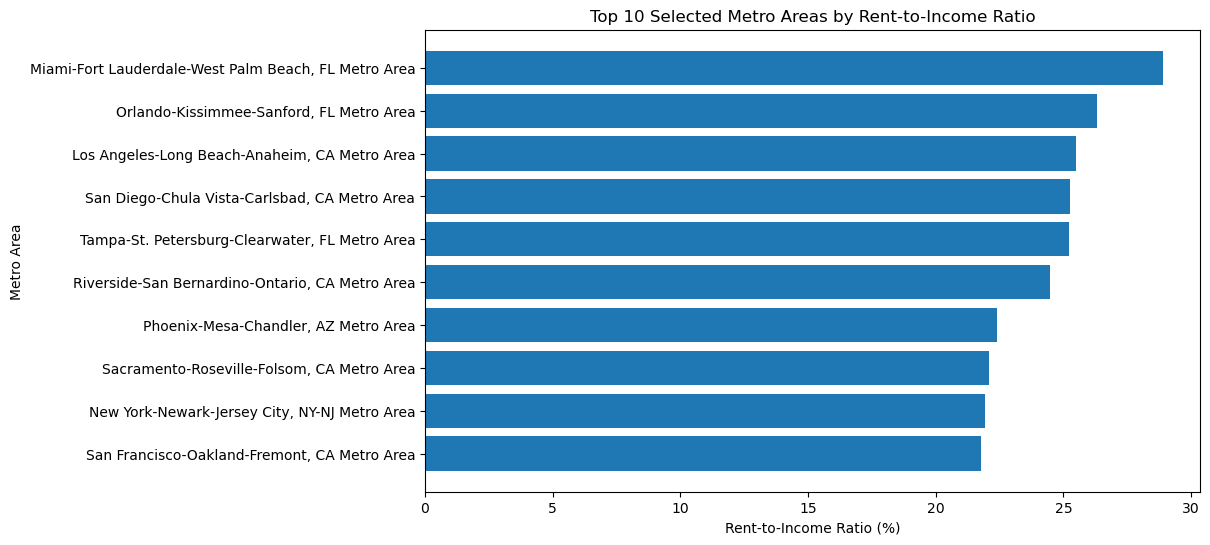

In [28]:
top10_burden = df_selected_sorted.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10_burden["metro_area"], top10_burden["rent_to_income_percent"])
plt.xlabel("Rent-to-Income Ratio (%)")
plt.ylabel("Metro Area")
plt.title("Top 10 Selected Metro Areas by Rent-to-Income Ratio")
plt.gca().invert_yaxis()
plt.show()

In [29]:
top10_burden[[
    "metro_area",
    "median_household_income",
    "median_gross_rent",
    "monthly_income",
    "rent_to_income_percent",
    "affordability_level"
]].round(2)

,metro_area,median_household_income,median_gross_rent,monthly_income,rent_to_income_percent,affordability_level
545,"Miami-Fort Lauderdale-West Palm Beach, FL Metr...",73481,1770,6123.42,28.91,Relatively Affordable
631,"Orlando-Kissimmee-Sanford, FL Metro Area",75611,1659,6300.92,26.33,Relatively Affordable
496,"Los Angeles-Long Beach-Anaheim, CA Metro Area",93525,1987,7793.75,25.49,Relatively Affordable
749,"San Diego-Chula Vista-Carlsbad, CA Metro Area",102285,2154,8523.75,25.27,Relatively Affordable
834,"Tampa-St. Petersburg-Clearwater, FL Metro Area",71254,1497,5937.83,25.21,Relatively Affordable
713,"Riverside-San Bernardino-Ontario, CA Metro Area",86031,1756,7169.25,24.49,Relatively Affordable
662,"Phoenix-Mesa-Chandler, AZ Metro Area",84703,1581,7058.58,22.40,Relatively Affordable
733,"Sacramento-Roseville-Folsom, CA Metro Area",93986,1729,7832.17,22.08,Relatively Affordable
607,"New York-Newark-Jersey City, NY-NJ Metro Area",97334,1780,8111.17,21.95,Relatively Affordable
753,"San Francisco-Oakland-Fremont, CA Metro Area",133780,2426,11148.33,21.76,Relatively Affordable


### Interpretation

Among the 29 selected Metro Areas, **Miami-Fort Lauderdale-West Palm Beach, FL Metro Area** had the highest `Rent-to-Income Ratio`.

Several Metro Areas in **Florida** and **California** appeared in the top 10, suggesting that some major rental markets in these states may have higher housing affordability pressure.

However, the highest ratio among the selected Metro Areas was still below the **30% cost-burden threshold**. This means that, based on median household income and median gross rent, none of the selected major Metro Areas were classified as cost burdened.

> This does not mean that all renters in these Metro Areas experience low housing burden. It only means that the median household, compared with median rent, does not exceed the 30% threshold.

This shows one limitation of using median values: median household income may not reflect the experience of lower-income renters.

## Analysis 2: Top 10 Metro Areas by Median Gross Rent

This analysis ranks the selected Metro Areas by **median gross rent**.

The purpose is to compare rent prices with the `Rent-to-Income Ratio` ranking and see whether the highest-rent areas are also the areas with the highest rental burden.


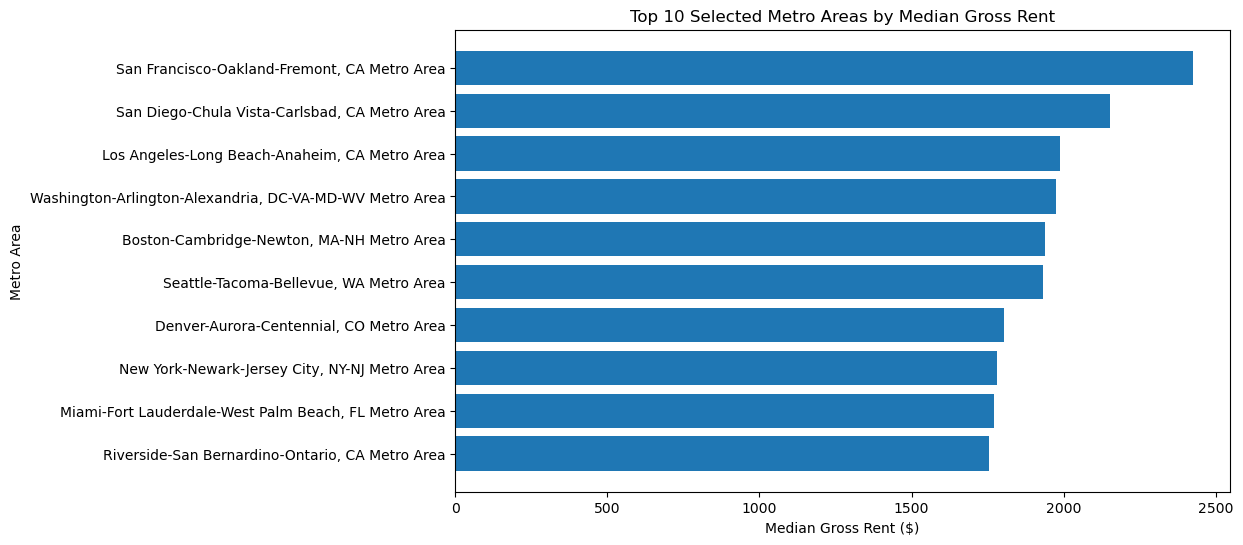

In [30]:
top10_rent = df_selected.sort_values("median_gross_rent", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10_rent["metro_area"], top10_rent["median_gross_rent"])
plt.xlabel("Median Gross Rent ($)")
plt.ylabel("Metro Area")
plt.title("Top 10 Selected Metro Areas by Median Gross Rent")
plt.gca().invert_yaxis()
plt.show()

In [31]:
top10_rent[[
    "metro_area",
    "median_household_income",
    "median_gross_rent",
    "monthly_income",
    "rent_to_income_percent",
    "affordability_level"
]].round(2)

,metro_area,median_household_income,median_gross_rent,monthly_income,rent_to_income_percent,affordability_level
753,"San Francisco-Oakland-Fremont, CA Metro Area",133780,2426,11148.33,21.76,Relatively Affordable
749,"San Diego-Chula Vista-Carlsbad, CA Metro Area",102285,2154,8523.75,25.27,Relatively Affordable
496,"Los Angeles-Long Beach-Anaheim, CA Metro Area",93525,1987,7793.75,25.49,Relatively Affordable
892,"Washington-Arlington-Alexandria, DC-VA-MD-WV M...",123896,1975,10324.67,19.13,Relatively Affordable
104,"Boston-Cambridge-Newton, MA-NH Metro Area",112484,1940,9373.67,20.70,Relatively Affordable
769,"Seattle-Tacoma-Bellevue, WA Metro Area",112594,1932,9382.83,20.59,Relatively Affordable
225,"Denver-Aurora-Centennial, CO Metro Area",102339,1805,8528.25,21.16,Relatively Affordable
607,"New York-Newark-Jersey City, NY-NJ Metro Area",97334,1780,8111.17,21.95,Relatively Affordable
545,"Miami-Fort Lauderdale-West Palm Beach, FL Metr...",73481,1770,6123.42,28.91,Relatively Affordable
713,"Riverside-San Bernardino-Ontario, CA Metro Area",86031,1756,7169.25,24.49,Relatively Affordable


### Interpretation

This chart shows which selected Metro Areas have the **highest median gross rent**.

While these areas represent expensive rental markets, high rent alone does not fully explain **housing affordability**. A Metro Area can have high rent, but if local income is also high, the actual rent burden may be lower than expected.

> This is why rent and income need to be analyzed together when evaluating housing affordability.

This comparison helps answer one of the main project questions: high-rent Metro Areas are not always the areas with the highest rental burden.

## Analysis 3: Median Household Income vs Median Gross Rent

This scatter plot compares **median household income** and **median gross rent** directly.

The goal is to see whether higher-income Metro Areas also tend to have higher rents, and whether some Metro Areas have rent levels that appear high relative to local income.


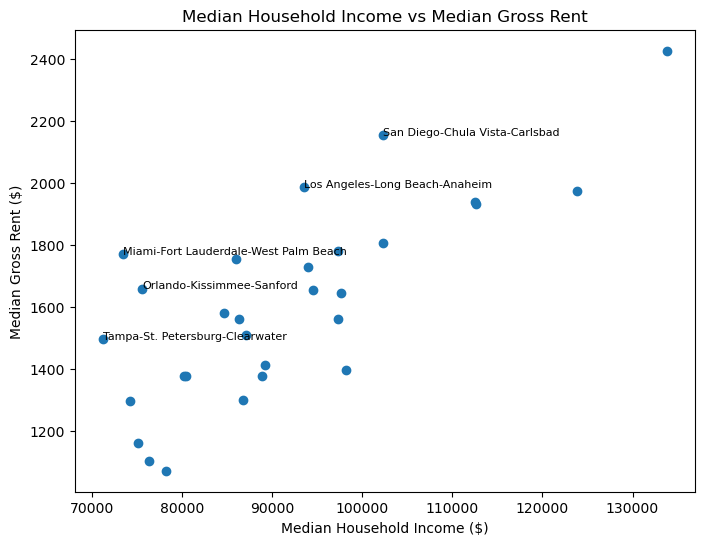

In [32]:
plt.figure(figsize=(8, 6))
plt.scatter(df_selected["median_household_income"], df_selected["median_gross_rent"])

plt.xlabel("Median Household Income ($)")
plt.ylabel("Median Gross Rent ($)")
plt.title("Median Household Income vs Median Gross Rent")

for _, row in df_selected.iterrows():
    if row["rent_to_income_percent"] >= 25:
        plt.annotate(
            row["metro_area"].split(",")[0],
            (row["median_household_income"], row["median_gross_rent"]),
            fontsize=8
        )

plt.show()

### Interpretation

The scatter plot shows the relationship between **median household income** and **median gross rent**.

In general, many higher-income Metro Areas also have higher rent levels. However, rental burden depends on the balance between income and rent, not just one variable.

Metro Areas with relatively high `Rent-to-Income Ratio` may indicate stronger rental market pressure, especially when rent is high compared to local income.


## Analysis 4: Rental Market Pressure Comparison

This section compares two different ways of looking at rental markets:

- **Expensive rental markets**: Metro Areas with high median gross rent
- **Pressured rental markets**: Metro Areas with high rent-to-income ratio

In real estate analysis, rent price alone does not fully describe market pressure. A market can have high rent, but if local income is also high, the rent burden may be more manageable.

This comparison helps identify which Metro Areas may have stronger rental affordability pressure relative to local income.

In [33]:
# Create ranking columns
df_selected["rent_rank"] = df_selected["median_gross_rent"].rank(ascending=False, method="min")
df_selected["burden_rank"] = df_selected["rent_to_income_percent"].rank(ascending=False, method="min")

# Select comparison columns
market_pressure_comparison = df_selected[[
    "metro_area",
    "median_gross_rent",
    "rent_to_income_percent",
    "rent_rank",
    "burden_rank"
]].copy()

# Sort by burden rank
market_pressure_comparison = market_pressure_comparison.sort_values("burden_rank")

market_pressure_comparison.head(15)

,metro_area,median_gross_rent,rent_to_income_percent,rent_rank,burden_rank
545,"Miami-Fort Lauderdale-West Palm Beach, FL Metr...",1770,28.905431,9.0,1.0
631,"Orlando-Kissimmee-Sanford, FL Metro Area",1659,26.329502,12.0,2.0
496,"Los Angeles-Long Beach-Anaheim, CA Metro Area",1987,25.494787,3.0,3.0
749,"San Diego-Chula Vista-Carlsbad, CA Metro Area",2154,25.270568,2.0,4.0
834,"Tampa-St. Petersburg-Clearwater, FL Metro Area",1497,25.211216,19.0,5.0
713,"Riverside-San Bernardino-Ontario, CA Metro Area",1756,24.493497,10.0,6.0
662,"Phoenix-Mesa-Chandler, AZ Metro Area",1581,22.398262,15.0,7.0
733,"Sacramento-Roseville-Folsom, CA Metro Area",1729,22.075628,11.0,8.0
607,"New York-Newark-Jersey City, NY-NJ Metro Area",1780,21.945055,8.0,9.0
753,"San Francisco-Oakland-Fremont, CA Metro Area",2426,21.761100,1.0,10.0


### Interpretation

This comparison shows that the most expensive rental markets are not always the markets with the highest rent burden.

Some Metro Areas may have high median rent, but their rent-to-income ratio can be lower if local household income is also high. On the other hand, some Metro Areas may not have the highest rent levels, but still show stronger rental market pressure because rent takes up a larger share of local income.

From a real estate perspective, this suggests that affordability should be analyzed not only through rent prices, but also through the relationship between rent and local earning power.

> A high-rent market is not always the same as a high-pressure rental market.

## Key Findings

- Among the selected 29 Metro Areas, **Miami-Fort Lauderdale-West Palm Beach** had the highest `Rent-to-Income Ratio`.
- Several **Florida** and **California** Metro Areas appeared among the highest rent-burden markets in the selected sample.
- High rent alone does not fully explain housing affordability.
- Comparing rent with income provides a clearer view of **rental market pressure**.
- None of the selected 29 Metro Areas exceeded the **30% cost-burden threshold** when using median household income and median gross rent.
- This does not mean every renter in these areas has low housing burden. Median-based analysis may hide the housing burden experienced by lower-income renters.
- The comparison between rent ranking and burden ranking shows that expensive rental markets are not always the same as high-pressure rental markets.

## Limitations

This project uses **median household income** and **median gross rent**, which provide a useful overall picture of each Metro Area.

However, median values do not fully represent all renter experiences. Lower-income renters, students, and households with unstable income may face much higher housing burden than the median numbers suggest.

Because this project uses overall median household income, it may overestimate affordability for renters whose income is below the median.

This project also focuses on **29 selected Metro Areas**, so the results should not be interpreted as a full ranking of all U.S. housing markets.

## Future Improvements

Future versions of this project could expand the analysis by adding:

- More Metro Areas
- Poverty rate
- Median home value
- Renter household income instead of general household income
- Year-over-year affordability trends
- Map-based visualization
- A focused analysis on Wisconsin or Madison

These additions would make the project more detailed and help explain housing affordability from multiple angles.


In [34]:
df_selected_sorted.to_csv("selected_metro_housing_affordability.csv", index=False)

print("CSV file saved successfully.")

CSV file saved successfully.
